# Instructor Effectiveness Modeling — Accredian Data Science Internship

**Author:** [Atul Kumar]  
**Date:** March 2026  
**Dataset:** `instructor_effectiveness_dataset_2000_rows.csv`

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis](#2)
3. [Defining Instructor Effectiveness](#3)
4. [Aggregation to Instructor Level](#4)
5. [ML Model](#5)
6. [Model Evaluation](#6)
7. [Interpreting Results](#7)
8. [Mandatory Analysis Questions](#8)


## 1. Setup & Data Loading

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
SEED = 42
np.random.seed(SEED)

In [45]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [46]:
df=pd.read_csv('instructor_effectiveness_dataset_2000_rows.csv')
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [47]:
print(f"Shape: {df.shape}")
print(f"Unique instructors: {df['instructor_id'].nunique()}")
print(f"Unique courses: {df['course_id'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape: (2000, 12)
Unique instructors: 120
Unique courses: 25
Missing values: 0


## 2. Exploratory Data Analysis

> **Goal:** Understand distributions, relationships, and anomalies before modelling.


In [48]:
numeric_cols = ['completion_rate','dropout_rate','avg_score_improvement',
                'avg_quiz_score','avg_watch_time','assignment_submission_rate',
                'forum_activity_rate','avg_feedback_score','feedback_response_rate']

df[numeric_cols].describe().round(3)

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,0.603,0.395,27.036,77.956,0.777,0.753,0.250,4.207,0.737
std,0.160,0.163,5.717,10.696,0.145,0.148,0.101,0.419,0.149
min,0.300,0.020,6.159,40.387,0.287,0.251,0.000,2.640,0.260
25%,0.489,0.280,23.125,70.898,0.675,0.652,0.180,3.919,0.633
50%,0.603,0.395,26.939,78.021,0.780,0.756,0.250,4.206,0.737
75%,0.713,0.511,30.886,85.444,0.894,0.856,0.319,4.503,0.846
max,0.980,0.700,40.000,100.000,1.000,1.000,0.641,5.000,1.000


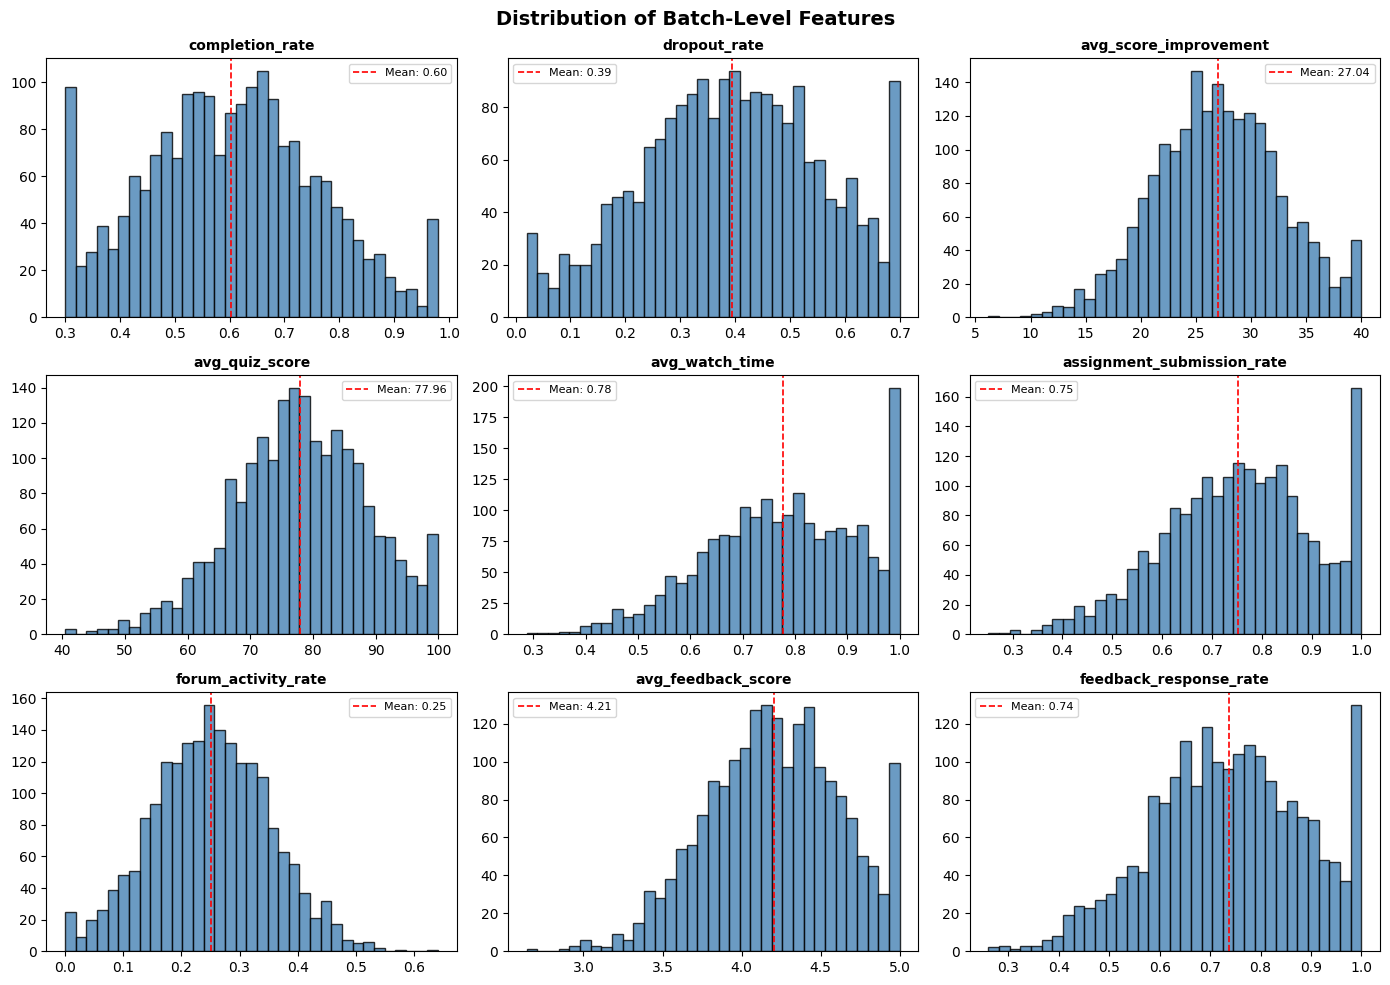

In [49]:
fig, axes = plt.subplots(3, 3, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=35,
                 color='steelblue',
                 edgecolor='black',
                 alpha=0.8)
    
    mean_val = df[col].mean()
    
    axes[i].axvline(mean_val,
                    color='red',
                    linestyle='--',
                    linewidth=1.2,
                    label=f"Mean: {mean_val:.2f}")
    
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution of Batch-Level Features", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Observations:**

- The variables `completion_rate` and `dropout_rate` appear to be strongly negatively correlated. This is expected because they   represent complementary outcomes: as completion increases, dropout naturally decreases.
Including both variables in the model may introduce redundancy and could lead to double-counting the same information. Therefore, for modeling purposes we retain `completion_rate` as the primary indicator of course success and exclude `dropout_rate`.
- The variable `avg_feedback_score` appears left-skewed, with most values concentrated between 4 and 5.
This suggests that learners tend to provide generally positive feedback, which is common in many rating systems due to response bias
- The `forum_activity_rate` variable shows a wide spread across batches, indicating meaningful variation in learner participation in discussion forums.
    
    This variability may reflect differences in:    
    - instructor encouragement of discussion
    - course design    
    - student engagement levels
      
- No missing values were detected across the dataset. This indicates that the dataset is clean and complete, allowing us to proceed with analysis and modeling without requiring imputation or additional preprocessing.

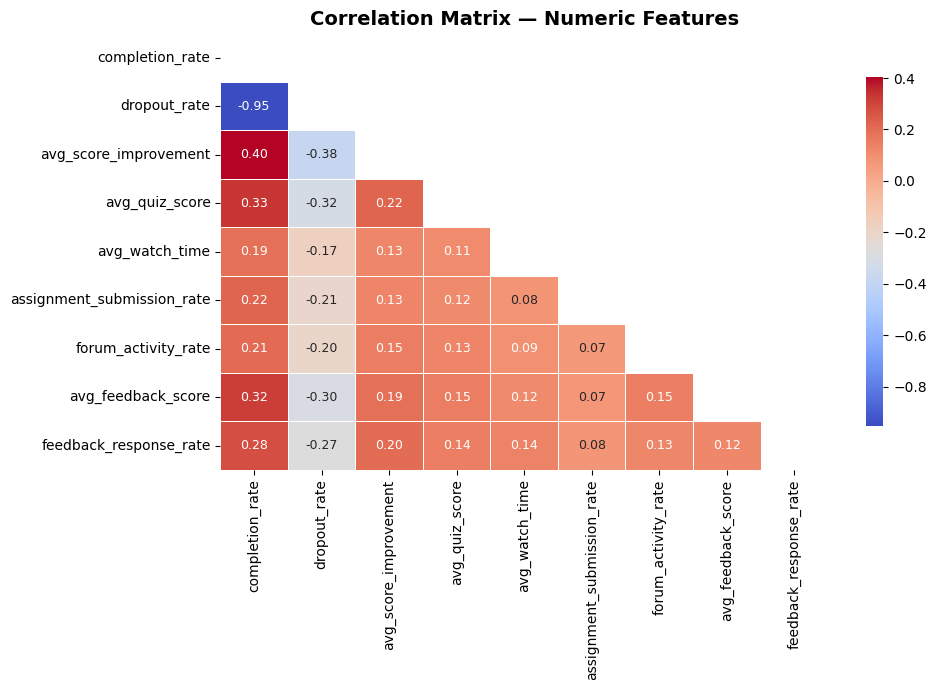

In [50]:
fig, ax = plt.subplots(figsize=(10,7))

corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool),k=0)

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":9},
    ax=ax
)

ax.set_title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**Correlation highlights:**
- `completion_rate` and `dropout_rate` have a very strong negative correlation (r ≈ -0.95).
This suggests a strong linear relationship where an increase in the rate of completion is accompanied by a proportional decrease in the rate of dropout.
Since the two features essentially contain the same information, including them would introduce redundancy.
- There is a moderate positive correlation between `avg_quiz_score` and `avg_score_improvement` with an r value of approximately 0.22. This implies that instructors whose students perform well in quizzes also show good learning improvement from the pre-course to the post-course.
- `avg_feedback_score` and `completion_rate` exhibit a moderate positive relationship (r ≈ 0.32).
Courses with higher learner satisfaction tend to have higher completion rates.

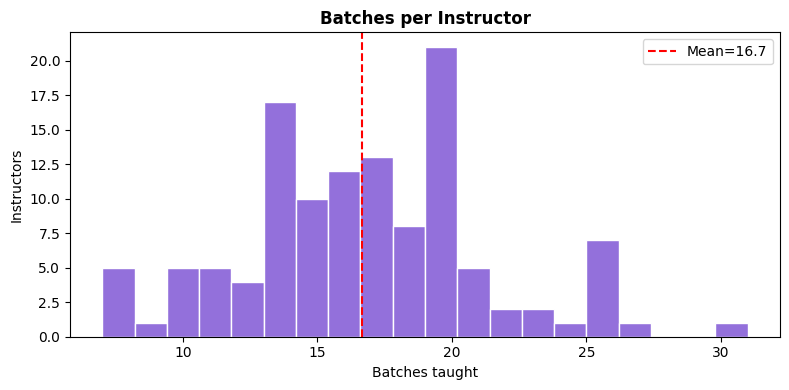

count    120.00
mean      16.67
std        4.58
min        7.00
25%       13.75
50%       17.00
75%       19.00
max       31.00
dtype: float64


In [51]:
# Batches per instructor
batch_counts = df.groupby('instructor_id').size()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(batch_counts,
        bins=20, 
        color='mediumpurple',
        edgecolor='white')
ax.axvline(batch_counts.mean(),
           color='red',
           linestyle='--', 
           label=f'Mean={batch_counts.mean():.1f}')

ax.set_xlabel('Batches taught')
ax.set_ylabel('Instructors')
ax.set_title('Batches per Instructor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(batch_counts.describe().round(2))


## 3. Defining Instructor Effectiveness

### 3.1 Idea

There is no specific column for instructor effectiveness in the dataset.  
Thus, we need to create a **score** based on key factors for instructor effectiveness.

A good instructor is one who can:

1. **Help students improve** - better quiz performance and improved performance over time  
2. **Keep students active** - viewing lectures, submitting assignments, and participating in forums  
3. **Help students complete the course** - high completion rate  
4. **Get positive feedback** - positive ratings from students

---
### 3.2 Composite Score

| Dimension | Features | Weight | Reason |
|-----------|----------|--------|--------|
| Learning | `avg_score_improvement`, `avg_quiz_score` | **30%** | Learning is the main goal of teaching |
| Engagement | `avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate` | **25%** | Active learners usually learn better |
| Retention | `completion_rate` | **25%** | Shows how many learners finish the course |
| Feedback | `avg_feedback_score × feedback_response_rate` | **20%** | Feedback shows learner satisfaction |

---

### 3.3 Feature Selection

We are not using `dropout_rate` as a feature, as it is **strongly related** with `completion_rate`.  
If completion rate is high, then dropout rate will be low, and vice versa.  
So, we are not using both features, as they will contain the same information.

---

### 3.4 Scaling

We are scaling our features, as they are of different ranges.  
We are scaling our features in a range between **0 and 1** for our final calculation.

In [52]:
# Min-Max normalization function
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

# Normalize features
df['score_improvement_norm'] = minmax(df['avg_score_improvement'])
df['quiz_score_norm'] = minmax(df['avg_quiz_score'])
df['feedback_score_norm'] = minmax(df['avg_feedback_score'])

df['watch_time_norm'] = minmax(df['avg_watch_time'])
df['assignment_rate_norm'] = minmax(df['assignment_submission_rate'])
df['forum_activity_norm'] = minmax(df['forum_activity_rate'])

# Compute effectiveness score
df['effectiveness_score'] = (
    0.30 * (0.5 * df['score_improvement_norm'] + 0.5 * df['quiz_score_norm']) +
    0.25 * (df['watch_time_norm'] + df['assignment_rate_norm'] + df['forum_activity_norm']) / 3 +
    0.25 * df['completion_rate'] +
    0.20 * df['feedback_score_norm'] * df['feedback_response_rate']
)

print("Batch-level effectiveness score:")
print(df['effectiveness_score'].describe().round(4))

Batch-level effectiveness score:
count    2000.0000
mean        0.5818
std         0.1031
min         0.2170
25%         0.5111
50%         0.5822
75%         0.6478
max         0.9296
Name: effectiveness_score, dtype: float64


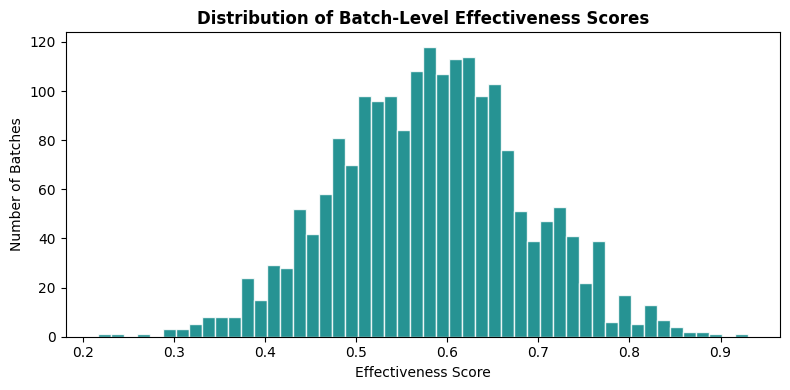

In [53]:
fig, ax = plt.subplots(figsize=(8,4))

ax.hist(df['effectiveness_score'],
        bins=50,
        color='teal',
        edgecolor='white',
        alpha=0.85)

ax.set_xlabel('Effectiveness Score')
ax.set_ylabel('Number of Batches')
ax.set_title('Distribution of Batch-Level Effectiveness Scores', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Aggregating to Instructor Level

### 4.1 Strategy

| Aggregation | Purpose |
|-------------|---------|
| `mean` | This will display the average performance for that instructor over all batches |
| `std` | This will display the instructor's consistency |
| `min` | This will display the lowest score for that instructor |
| `count` | This will display the number of batches that instructor has taught |

Instructors that have **taught fewer than 8 batches** are highlighted since their results are not necessarily very reliable.

---
### 4.2 Why Use These Statistics?

If we just use **mean** alone, we may not be able to identify inconsistency.

For example, an instructor could give **0.9 in one batch and 0.3 in another**.  
The average is good, but performance is not consistent.

So we also need to use:

- **std** → to check consistency  
- **min** → lowest performance

In [54]:
feature_cols = ['completion_rate','avg_score_improvement','avg_quiz_score',
                'avg_watch_time','assignment_submission_rate','forum_activity_rate',
                'avg_feedback_score','feedback_response_rate','effectiveness_score']

agg_dict = {col: ['mean','std','min'] for col in feature_cols}
agg_dict['batch_id'] = 'count'

instructor_df = df.groupby('instructor_id').agg(agg_dict)
instructor_df.columns = ['_'.join(c).strip() for c in instructor_df.columns]
instructor_df = instructor_df.rename(columns={'batch_id_count': 'batch_count'})
instructor_df = instructor_df.reset_index().fillna(0)

print(f"Instructor-level shape: {instructor_df.shape}")
instructor_df.head(3)


Instructor-level shape: (120, 29)


,instructor_id,completion_rate_mean,completion_rate_std,completion_rate_min,avg_score_improvement_mean,avg_score_improvement_std,avg_score_improvement_min,avg_quiz_score_mean,avg_quiz_score_std,avg_quiz_score_min,avg_watch_time_mean,avg_watch_time_std,avg_watch_time_min,assignment_submission_rate_mean,assignment_submission_rate_std,assignment_submission_rate_min,forum_activity_rate_mean,forum_activity_rate_std,forum_activity_rate_min,avg_feedback_score_mean,avg_feedback_score_std,avg_feedback_score_min,feedback_response_rate_mean,feedback_response_rate_std,feedback_response_rate_min,effectiveness_score_mean,effectiveness_score_std,effectiveness_score_min,batch_count
0,I_001,0.543887,0.084611,0.375660,26.641462,6.074232,16.341942,78.900194,8.878089,66.462439,0.766513,0.131532,0.555332,0.726893,0.145189,0.406699,0.240551,0.094695,0.000000,4.217743,0.388802,3.516045,0.694858,0.166455,0.413349,0.556894,0.069985,0.413389,25
1,I_002,0.730874,0.103691,0.553844,30.166242,3.939007,24.042172,81.737198,9.843168,68.770533,0.837393,0.112701,0.624976,0.774394,0.141096,0.527085,0.289610,0.088573,0.102253,4.343002,0.440235,3.577842,0.784338,0.114460,0.578434,0.664832,0.061890,0.583601,20
2,I_003,0.768447,0.120452,0.568270,29.977813,5.074705,19.904075,81.590928,11.064673,59.142412,0.818441,0.158280,0.526231,0.779606,0.121712,0.570225,0.296224,0.082414,0.130071,4.450034,0.386108,3.555688,0.812132,0.141805,0.578718,0.683917,0.070339,0.578502,18


In [55]:
instructor_df['low_sample'] = instructor_df['batch_count'] < 8
print(f"Low-sample instructors (<8 batches): {instructor_df['low_sample'].sum()}")

Low-sample instructors (<8 batches): 1


### 4.3 Assigning Effectiveness Tiers

To assign these levels of instructors, we create **groups of the mean effectiveness score**.

We divide our data into **tertiles** based on percentiles.

| Tier | Range | Label |
|------|-------|-------|
| Low | 0–33rd percentile | 0 |
| Medium | 34th–66th percentile | 1 |
| High | 67th–100th percentile | 2 |

This is done since **there is no specific score that makes an instructor good or bad**.  
Therefore, we divide our data into **three balanced groups** based on their scores.

Tier distribution:
tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


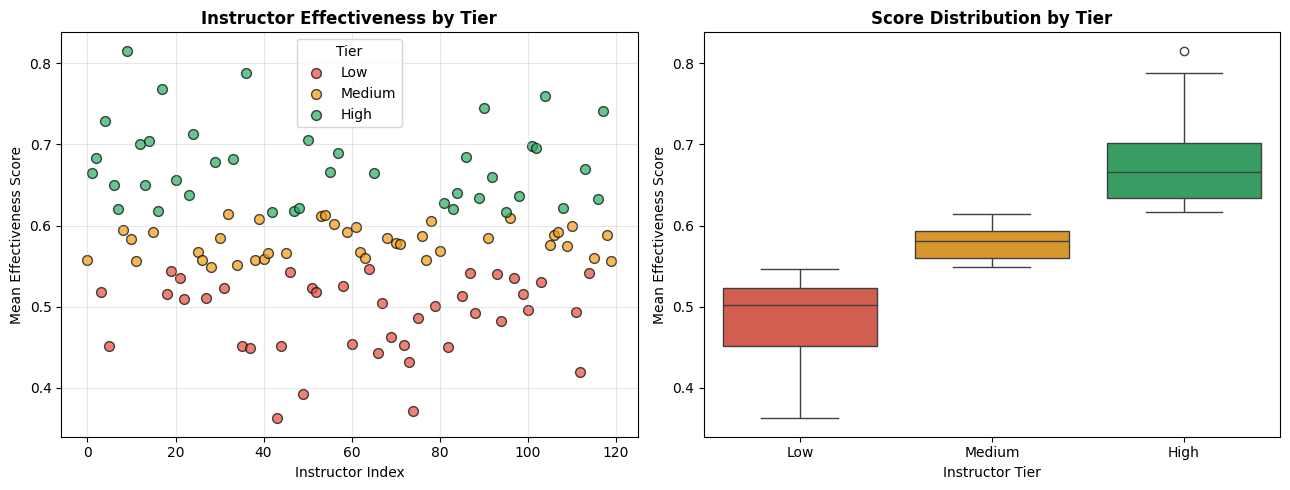

In [56]:
instructor_df['tier'] = pd.qcut(
    instructor_df['effectiveness_score_mean'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print("Tier distribution:")
print(instructor_df['tier'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {
    'Low': '#e74c3c',
    'Medium': '#f39c12',
    'High': '#27ae60'
}

#  Scatter Plot 
for tier, color in colors.items():
    s = instructor_df[instructor_df['tier'] == tier]

    axes[0].scatter(
        s.index,
        s['effectiveness_score_mean'],
        label=tier,
        color=color,
        alpha=0.7,
        s=50,
        edgecolors='black'
    )

axes[0].set_xlabel('Instructor Index')
axes[0].set_ylabel('Mean Effectiveness Score')
axes[0].set_title('Instructor Effectiveness by Tier', fontweight='bold')
axes[0].legend(title='Tier')
axes[0].grid(alpha=0.3)

# Box Plot 
plot_data = instructor_df[['effectiveness_score_mean', 'tier']].copy()

sns.boxplot(
    x='tier',
    y='effectiveness_score_mean',
    data=plot_data,
    order=['Low', 'Medium', 'High'],
    palette=colors,
    hue='tier',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Score Distribution by Tier', fontweight='bold')
axes[1].set_xlabel('Instructor Tier')
axes[1].set_ylabel('Mean Effectiveness Score')

plt.tight_layout()
plt.show()

## 5. Building the ML Model

### 5.1 Feature Selection

**Excluded:**

- `effectiveness_score_*` columns → derived from the same formula used to create the target. Including them would cause **label leakage**.
- `instructor_id` → only an identifier, not useful for prediction.
- `low_sample` → informational flag.

**Retained:**

- Mean, std, and min aggregates of original batch-level features
- `batch_count` → number of batches handled by the instructor

These features capture instructor performance patterns without leaking target information.

---

### 5.2 Model Choice — Random Forest (Primary)

| Model | Reason |
|------|------|
| **Random Forest** | Handles non-linear patterns, robust to noise, provides feature importance |
| Logistic Regression | Simple linear baseline, interpretable |
| Gradient Boosting | Strong ensemble model used to compare performance |

**Random Forest** was chosen as the primary model because it:
- captures non-linear relationships
- is robust to overfitting
- does not require feature scaling
- provides feature importance for interpretation

> Model selection focuses on **interpretability and reasoning**, not just accuracy.

In [57]:
# Exclude columns that cause leakage or are not useful
exclude = [c for c in instructor_df.columns if 'effectiveness_score' in c]
exclude += ['instructor_id', 'tier', 'low_sample']

# Remaining columns are used as features
feature_cols_model = [c for c in instructor_df.columns if c not in exclude]

# Feature matrix
X = instructor_df[feature_cols_model].values

# Target variable (encode tiers)
y = instructor_df['tier'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
}).values

# ---- Basic checks ----
print("Number of features:", len(feature_cols_model))
print("X shape:", X.shape)
print("y shape:", y.shape)

# Class distribution
print(
    "Class balance:",
    f"Low={np.sum(y==0)},",
    f"Medium={np.sum(y==1)},",
    f"High={np.sum(y==2)}"
)

Number of features: 25
X shape: (120, 25)
y shape: (120,)
Class balance: Low=40, Medium=40, High=40


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 90 | Test: 30


In [59]:
# Logistic Regression baseline
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=500, random_state=SEED))])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Low','Medium','High']))


=== Logistic Regression ===
              precision    recall  f1-score   support

         Low       0.83      1.00      0.91        10
      Medium       0.80      0.80      0.80        10
        High       1.00      0.80      0.89        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



In [60]:
# Random Forest 

rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("=== Random Forest ===")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Low','Medium','High']
))

=== Random Forest ===
              precision    recall  f1-score   support

         Low       1.00      0.90      0.95        10
      Medium       0.82      0.90      0.86        10
        High       0.90      0.90      0.90        10

    accuracy                           0.90        30
   macro avg       0.91      0.90      0.90        30
weighted avg       0.91      0.90      0.90        30



In [61]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=SEED
)

gb.fit(X_train, y_train)

# Predictions
y_pred_gb = gb.predict(X_test)

# Evaluation
print("=== Gradient Boosting ===")
print(classification_report(
    y_test,
    y_pred_gb,
    target_names=['Low','Medium','High']
))

=== Gradient Boosting ===
              precision    recall  f1-score   support

         Low       0.90      0.90      0.90        10
      Medium       0.82      0.90      0.86        10
        High       1.00      0.90      0.95        10

    accuracy                           0.90        30
   macro avg       0.91      0.90      0.90        30
weighted avg       0.91      0.90      0.90        30



## 6. Model Evaluation

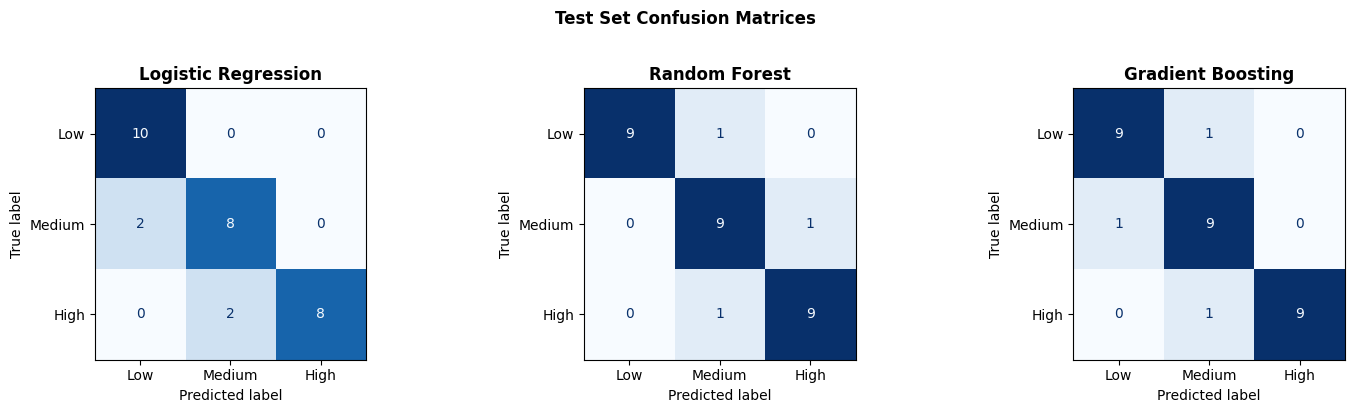

In [62]:
# Confusion Matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gb)
]

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low','Medium','High']
    )

    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontweight='bold')

plt.suptitle("Test Set Confusion Matrices", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [63]:
# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {
    'Logistic Regression': cross_val_score(lr_pipe, X, y, cv=cv, scoring='f1_weighted'),
    'Random Forest': cross_val_score(rf, X, y, cv=cv, scoring='f1_weighted'),
    'Gradient Boosting': cross_val_score(gb, X, y, cv=cv, scoring='f1_weighted')
}

print("=== 5-Fold CV Weighted F1 ===")

for name, scores in cv_results.items():
    print(f"{name:22s}  mean={scores.mean():.3f}  std={scores.std():.3f}")

=== 5-Fold CV Weighted F1 ===
Logistic Regression     mean=0.828  std=0.059
Random Forest           mean=0.873  std=0.051
Gradient Boosting       mean=0.821  std=0.047


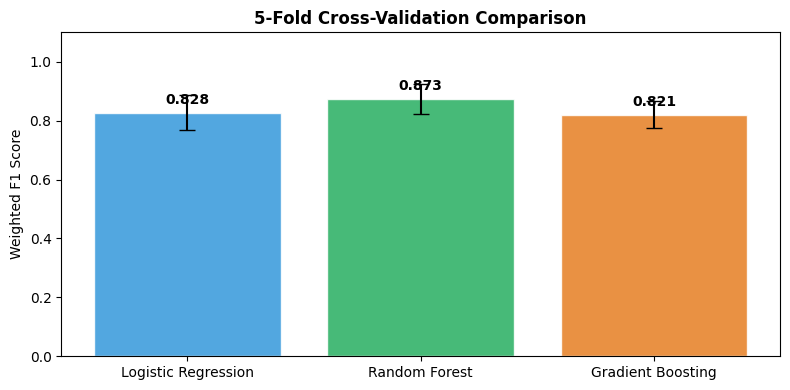

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))

names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std() for n in names]

bars = ax.bar(
    names,
    means,
    yerr=stds,
    capsize=6,
    color=['#3498db', '#27ae60', '#e67e22'],
    alpha=0.85,
    edgecolor='white'
)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Weighted F1 Score')
ax.set_title('5-Fold Cross-Validation Comparison', fontweight='bold')

# Annotate bars with scores
for bar, m in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        m + 0.03,
        f'{m:.3f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

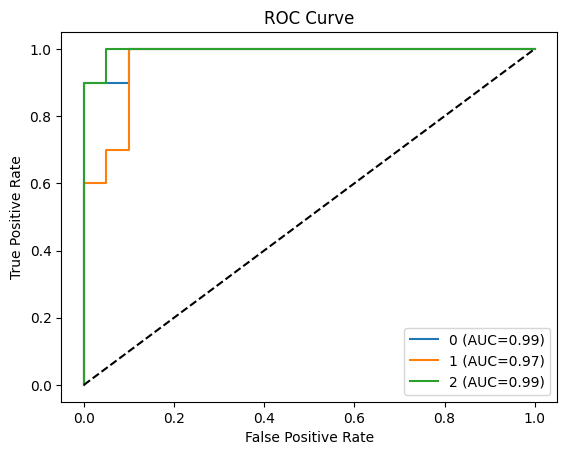

In [72]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = rf.classes_

y_test_bin = label_binarize(y_test, classes=classes)
y_prob = rf.predict_proba(X_test)

for i in range(len(classes)):
    
    if y_test_bin[:, i].sum() == 0:
        print(f"Skipping {classes[i]} (no samples in y_test)")
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Evaluation Discussion

**Why Weighted F1?**

While the data is balanced in both tiers, **Weighted F1 Score** is still used because it takes both **precision and recall** into account for each class. This will provide a better estimate of the model's performance than using accuracy.

---

**Class Imbalance**

Class imbalance is not an issue in the data because it was divided into tiers based on tertiles.  
In general, in real data, most instructors might be in one class, and then techniques like **class_weight='balanced'** or **SMOTE** could be used.

---

**Precision vs Recall**

When deciding between precision and recall, it depends on what the model will be used for:

- If it's something like **contract negotiations** or **salary**, then **precision** on the **Low tier** is important so that no good instructors are incorrectly labeled.
- If it's something like **support** or **coaching**, then **recall** on the **Low tier** is important so that no instructors are overlooked.

The model balances both, but it depends on what the model is being used for.

## 7. Interpreting the Results

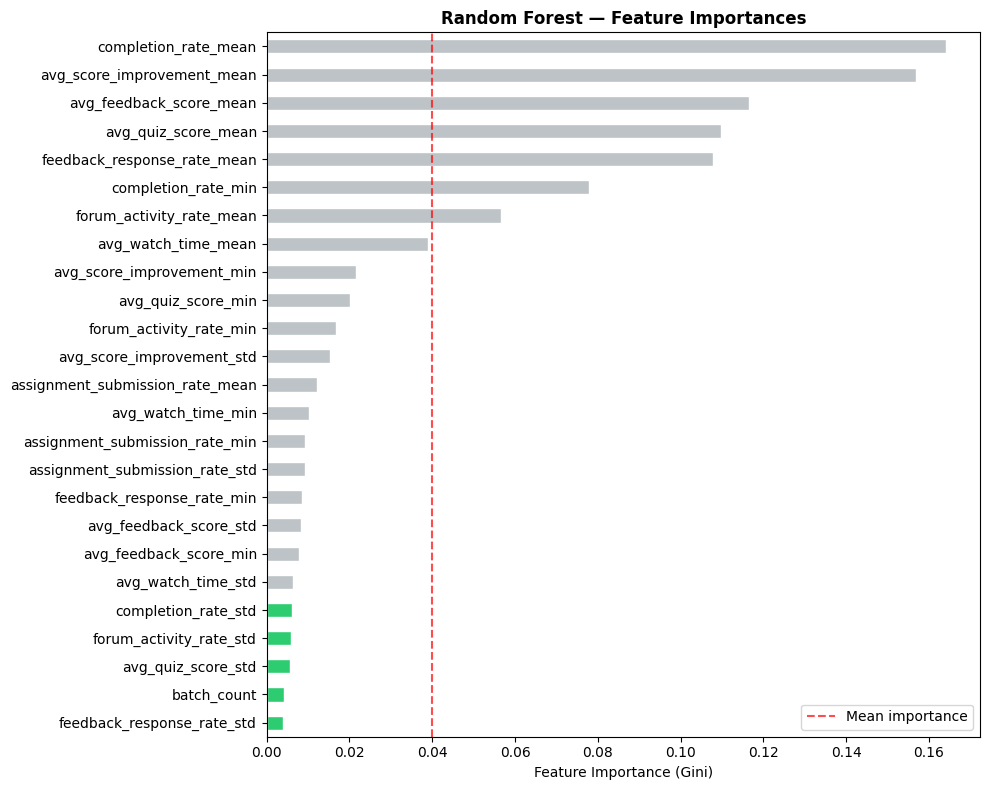

Top 10 Features:
completion_rate_mean           0.1641
avg_score_improvement_mean     0.1568
avg_feedback_score_mean        0.1165
avg_quiz_score_mean            0.1098
feedback_response_rate_mean    0.1077
completion_rate_min            0.0778
forum_activity_rate_mean       0.0567
avg_watch_time_mean            0.0390
avg_score_improvement_min      0.0215
avg_quiz_score_min             0.0201
dtype: float64


In [65]:
# Feature Importance
importances = rf.feature_importances_

feat_imp = pd.Series(
    importances,
    index=feature_cols_model
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

colors_imp = ['#2ecc71' if i < 5 else '#bdc3c7' for i in range(len(feat_imp))]

feat_imp.plot(
    kind='barh',
    ax=ax,
    color=colors_imp[::-1],
    edgecolor='white'
)

ax.invert_yaxis()
ax.axvline(feat_imp.mean(), color='red', linestyle='--', alpha=0.7, label='Mean importance')

ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importances', fontweight='bold')

ax.legend()

plt.tight_layout()
plt.show()

print("Top 10 Features:")
print(feat_imp.head(10).round(4))

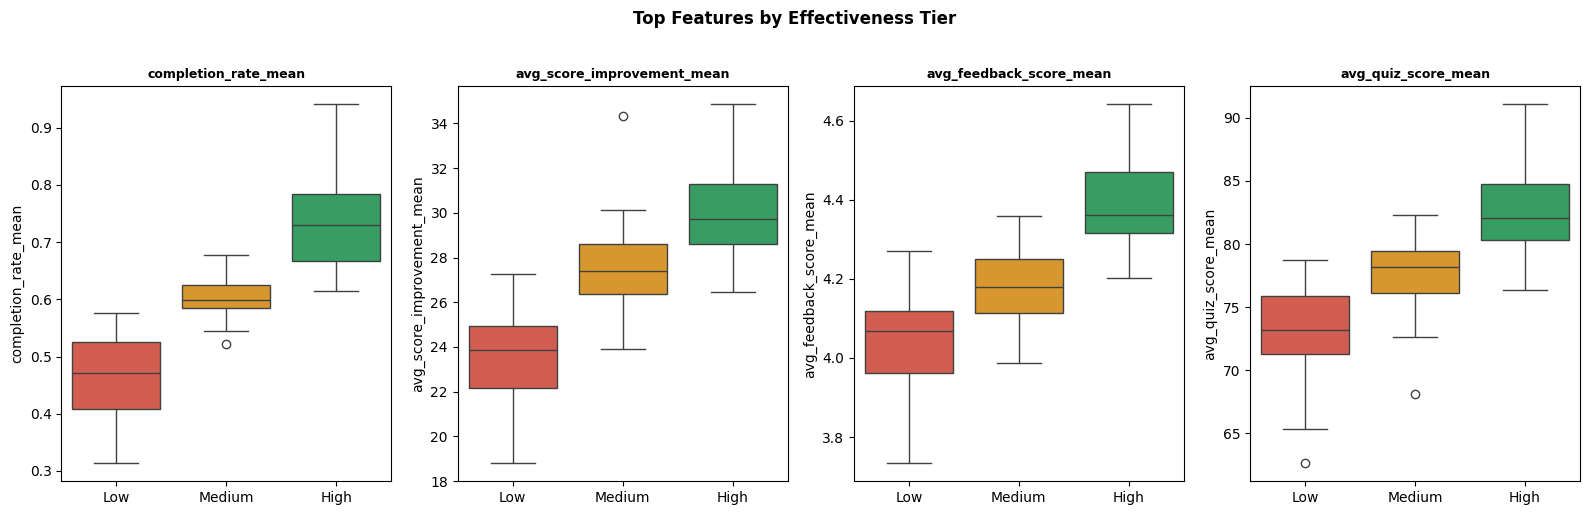

In [66]:
# Top 4 features by tier

top4 = feat_imp.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

palette = {'Low':'#e74c3c','Medium':'#f39c12','High':'#27ae60'}

for ax, feat in zip(axes, top4):
    plot_df = instructor_df[[feat, 'tier']].copy()

    sns.boxplot(
        x='tier',
        y=feat,
        data=plot_df,
        order=['Low','Medium','High'],
        palette=palette,
        hue='tier',        
        legend=False,
        ax=ax
    )

    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle(
    "Top Features by Effectiveness Tier",
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Plain Language Interpretation

**What differentiates High and Low tier instructors?**

1. **Completion Rate**  
High tier instructors ensure learners complete the course. Even their worst batches have a good completion rate.

2. **Improvement in Score**  
High tier instructors ensure learners improve their score, indicating improvement in their learning process.

3. **Assignment Submission**  
Regular submission of assignments by learners indicates a good instructor who keeps learners engaged and motivated.

4. **Consistency**  
High tier instructors are consistent in their performance. If there is a significant difference between batches, the instructor might not be performing well.  

---

**Product Recommendations**

- **High tier instructors** - Use these as mentors for premium cohorts.
- **Medium tier instructors** - Use these to coach learners to overcome their weak areas.
- **Low tier instructors** - Use these to offer learners structured support.

## 8. Mandatory Analysis Questions
---
### Q1. Which features most influenced instructor effectiveness?

The most important features from the Random Forest model were:

- **`completion_rate_mean`**  
  Instructors with high completion rates are better at keeping learners engaged until the end of the course.

- **`avg_score_improvement_mean`**  
  This feature reflects how much learners improved from pre-test to post-test. It reflects the impact of teaching.

- **`assignment_submission_rate_mean`**  
  Instructors with high assignment submission rates have learners who are motivated to complete the work.

These features are important aspects of teaching quality: **retention, learning improvement, and engagement.**

---
### Q2. Which variables could be misleading?

The variables might be affected by external factors.

| Variable | Possible Issue |
|--------|--------|
| `avg_feedback_score` | Learners might give high marks to courses they find easy, not necessarily to the instructors. |
| `completion_rate` | Courses that are easier will naturally have a higher completion rate. |
| `avg_quiz_score` | Quizzes might be easier or harder depending on the course. |
| `forum_activity_rate` | Some learner groups might be more active on the forums than others. |
| `avg_score_improvement` | Beginners will naturally improve more than advanced learners. |

---
### Q3. How could this model fail in real use?

The possible limitations are:

- **Data changes over time** – new course formats or learner groups may be introduced.
- **Metric gaming** – instructors might be tempted to optimize for metrics rather than learning.
- **Label dependency** – the target tiers are based on the same metrics as the features.
- **Averaging issues** – averaging over batches might obscure recent progress.
- **Small sample sizes** – instructors with fewer batches might not have reliable scores.
- **Causality problem** – improved learner cohorts might boost instructor scores.

---
### Q4. What additional data would improve the analysis?

Data that would improve the model:

| Data | Why it helps |
|------|------|
| Learner baseline scores | Allows for the differentiation of instructor effect and learner ability |
| Course difficulty | Allows for adjustment in learner completion and quiz scores |
| Batch timestamps | Monitors the improvement of instructors over time |
| Peer review | Gives expert feedback on teaching effectiveness |
| Post-course outcomes | Monitors learner success after the course |
| Instructor experience | Helps understand differences between instructors |
| Learner feedback comments | Gives more in-depth feedback on learners |

---
### Q5. Should this model be used for instructor evaluation?

**Yes – as a support tool.  
No – as a fully automated decision system.**

**Benefits**
- Objective, data-driven insights.
- Potentially identify those who may need extra support.
- Easy scalability for large numbers of instructors.

**Risks**
- The effectiveness score is constructed, not ground truth.
- The impact of external factors (course difficulty, quality of cohort) is unknown.
- High-stakes decisions should not be made solely based on an automated model.

**Recommendations**
- The model should be used as a support tool for improvement discussions, with human review for decisions.

---

## Summary

| Step | Decision | Reason |
|-----|-----|-----|
| Effectiveness Score | Weighted composite | Considers various aspects of teaching quality |
| Tier Assignment | Tertile split | Balances the groups |
| Aggregation | Mean + Std + Min | Considers average and consistency |
| Model | Random Forest | Can handle non-linear relationships and provide feature importances |
| Evaluation | Weighted F1 + 5-fold CV | More robust metric than accuracy alone |

**The objective is not simply to achieve good prediction accuracy, but to obtain useful insights about instructor performance.**
